In [1]:

import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "Loop_MTP_paper_expert"


In [3]:
mtp_id = "xg57qmkz"
nonmtp_id = "whvom7hm"

GATE_BIAS_PREFIX_TEMPLATE = "recurrence_embedding_stats recurrence_embedding_stats/avg_cosine_similarity_layer_0_step_{iter}"
GATE = "recurrence_embedding_stats recurrence_embedding_stats/avg_cosine_similarity_layer_0_combined_vs_step_{iter}"
STEP_COL = "_step"   # actual column name in the W&B history DataFrame

# Colors distinguish runs; marker shapes distinguish seen_steps checkpoints
COLORS_RUNS   = plt.cm.Set2.colors
STEP_MARKERS  = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "p"]

# ── W&B connection ──────────────────────────────────────────────────────────
# `run` is the handle later (single-run) cells call `.history(...)` on.
api = wandb.Api()
run_mtp    = api.run(f"{ENTITY}/loop_MTP_paper/{mtp_id}")
run_nonmtp = api.run(f"{ENTITY}/loop_MTP_paper/{nonmtp_id}")
run = run_mtp   # default handle used by single-run cells

In [4]:
max_iters = 9

In [5]:
PALETTE    = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.75, 2)]

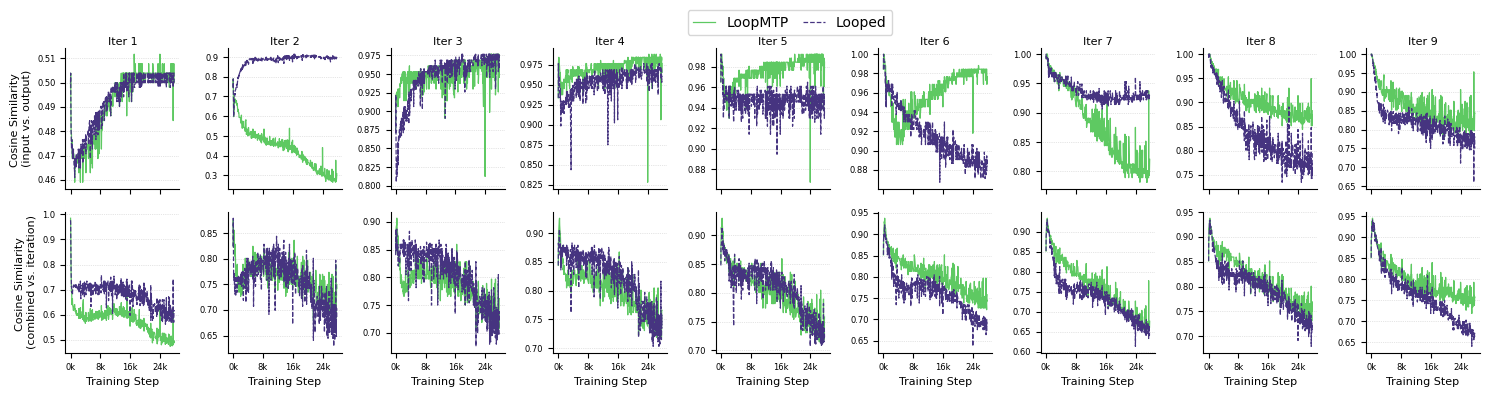

In [8]:

# ── Avg. cosine similarity: 2 variants × 3 loop iterations → 2x3 grid ────────
# Both runs overlaid in every panel (MTP vs. non-MTP).
# Row 0: per-step similarity         (GATE_BIAS_PREFIX_TEMPLATE → "..._step_{iter}")
# Row 1: combined-vs-step similarity (GATE                       → "..._combined_vs_step_{iter}")
ROW_TEMPLATES = [
    ("Cosine Similarity \n(input vs. output)", GATE_BIAS_PREFIX_TEMPLATE),
    ("Cosine Similarity \n(combined vs. iteration)", GATE),
]
RUNS = [
    ("LoopMTP",     run_mtp,    PALETTE[1], "-"),
    ("Looped", run_nonmtp, PALETTE[0], "--"),
]

# Fetch each run's history once (all 6 keys at a time)
sim_keys = [t.replace("{iter}", str(i)) for _, t in ROW_TEMPLATES for i in range(max_iters)]
run_hist = {}
for label, r, _, _ in RUNS:
    h = r.history(keys=sim_keys, pandas=True)
    run_hist[label] = h.sort_values(STEP_COL).reset_index(drop=True)

fig, axes = plt.subplots(len(ROW_TEMPLATES), max_iters,
                         figsize=(15.0, 3.8), sharex=True)

for r_idx, (row_label, template) in enumerate(ROW_TEMPLATES):
    for i in range(max_iters):
        ax  = axes[r_idx, i]
        key = template.replace("{iter}", str(i))

        for label, _, color, ls in RUNS:
            hist  = run_hist[label]
            col   = hist[key].dropna()
            steps = hist.loc[col.index, STEP_COL]
            ax.plot(steps, col.values, color=color, linestyle=ls,
                    linewidth=0.9, label=label)

        if r_idx == 0:
            ax.set_title(f"Iter {i + 1}", fontsize=8, pad=2)
        if r_idx == len(ROW_TEMPLATES) - 1:
            ax.set_xlabel("Training Step", fontsize=8)
        if i == 0:
            ax.set_ylabel(row_label, fontsize=8)

        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=6)

# Single shared legend (one entry per run)
handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=len(RUNS),
#            frameon=False, fontsize=8, bbox_to_anchor=(0.5, 1.0))

fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.53, 1.05),
    ncol=len(handles),
    columnspacing=1.0,
    handlelength=1.6,
    frameon=True,
    framealpha=0.8,
    edgecolor="#cccccc",
)

# fig.suptitle("Average Cosine Similarity Between Embeddings", fontsize=10, y=1.08)
# fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
fig.tight_layout()
fig.savefig(f"./plots/cosine_similarity_2x3_L={max_iters}_both.pdf")
plt.show()
